# Modelo 4 — Análisis final de experimentos

**Qué es el Modelo 4.** MILP que asigna cursos de dos bloques consecutivos a
salas, minimizando el costo total de movimiento estudiantil
`sum f_ik * c_rs * z_ikrs`, con `z_ikrs` linealizando `x_ir * y_ks`
(McCormick). `x`, `y` binarias; `z` continua en [0,1].

**Matriz detallada sala–sala.** `c_rs` se construye con distancia euclidiana
3D entre salas (coord_z = piso × altura) más una penalización por tipo de
transición: misma sala (0), mismo piso, distinto piso, cambio de edificio.

**Edificios y pisos.** Cada sala pertenece a un edificio y piso, con
coordenadas físicas; esto hace que moverse dentro del edificio sea barato y
cambiar de edificio sea caro.

**Carreras y años en los flujos.** Los flujos `f_ik` se generan con pesos:
altos entre cursos de la misma carrera y año, medios entre años de la misma
carrera, bajos entre carreras (electivos). Además hay **estudiantes libres**
(salen tras el bloque 1) y **estudiantes entrantes** (no tuvieron clases en
el bloque 1 pero sí en el 2). Ninguno genera costo, pero ambos afectan los
tamaños de los cursos y, por tanto, las restricciones de capacidad:
`sum_k f_ik + libres_i = tamano_i` y `sum_i f_ik + entrantes_k = tamano_k`.

**Análisis de complejidad.** Cómo crece el modelo (variables `z`,
restricciones de linealización) con el tamaño de la instancia.

**Análisis de escalabilidad.** Cómo responde el solver (tiempo, gap) al
aumentar I, K y R (Familia A).

**Gap de optimalidad.** `(obj − best_bound) / obj`: distancia relativa entre
la mejor solución encontrada y la mejor cota inferior. Gap 0 = óptimo
certificado; gap > 0 con TIME_LIMIT = solución factible sin certificado.

**Mejora frente al azar.** `(costo_azar_promedio − obj) / costo_azar_promedio × 100`,
con 10 asignaciones aleatorias factibles como línea base.

**Sobreoferta de salas.** Familia B: con I=K=18 fijos se aumenta R
(18→36) para medir el efecto de capacidades/salas excedentes sobre el costo,
el tiempo de resolución y las salas sin usar.


## Carga de resultados reales
El pipeline se ejecuta desde terminal con:
```bash
python src/correr_experimentos_m4.py
python src/construir_notebook_final.py
```

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
if not (BASE / "outputs").exists():     # permite ejecutar desde notebooks/
    BASE = BASE.parent
DIR_RES = BASE / "outputs" / "resultados"
DIR_GRAF = BASE / "outputs" / "graficos"
DIR_GRAF.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DIR_RES / "resultados_modelo4.csv")
fa = df[df["familia"] == "A_escalabilidad"].sort_values("I").copy()
fb = df[df["familia"] == "B_sobreoferta"].sort_values("R").copy()
df


,instancia,familia,I,K,R,edificios,carreras,num_x,num_y,num_z,...,salas_no_usadas_b2,total_libres,total_entrantes,time_limit,costo_recalculado,costo_misma_sala,n_random_exitosas,estudiantes_misma_sala_azar_promedio,estudiantes_mismo_edificio_azar_promedio,estudiantes_cambio_edificio_azar_promedio
0,M4_E12,A_escalabilidad,12,12,12,3,3,109,129,7215,...,0,39,12,300,1031.1683,0.0,10,28.3,108.9,255.8
1,M4_E16,A_escalabilidad,16,16,16,4,4,195,211,22225,...,0,57,9,600,3159.9299,0.0,10,36.8,110.5,414.7
2,M4_E20,A_escalabilidad,20,20,20,4,4,302,318,41546,...,0,71,39,900,3597.2274,0.0,10,38.9,123.9,515.2
3,M4_E24,A_escalabilidad,24,24,24,5,5,455,503,95361,...,0,73,33,1200,4331.9939,0.0,10,32.5,130.9,641.6
4,M4_S18_R18,B_sobreoferta,18,18,18,4,4,257,285,33874,...,0,56,31,600,2652.4134,0.0,10,34.0,121.2,483.8
5,M4_S18_R24,B_sobreoferta,18,18,24,4,4,305,344,53090,...,6,55,30,600,2930.4822,0.0,10,39.4,120.9,455.7
6,M4_S18_R30,B_sobreoferta,18,18,30,4,4,413,464,90414,...,12,62,22,900,2278.2357,0.0,10,26.6,128.6,459.8
7,M4_S18_R36,B_sobreoferta,18,18,36,4,4,553,583,166570,...,18,65,33,1200,1794.9990,0.0,10,12.7,126.2,468.1


## Tabla resumen

In [2]:
cols = ["instancia", "familia", "I", "K", "R", "num_z", "num_constraints",
        "status", "obj_modelo", "best_bound", "mip_gap", "runtime",
        "mejora_vs_azar", "total_libres", "total_entrantes"]
tabla = df[[c for c in cols if c in df.columns]]
sin_solucion = tabla[tabla["obj_modelo"].isna()]
if len(sin_solucion):
    print("Instancias SIN solución factible reportada:",
          sin_solucion["instancia"].tolist())
tabla


,instancia,familia,I,K,R,num_z,num_constraints,status,obj_modelo,best_bound,mip_gap,runtime,mejora_vs_azar,total_libres,total_entrantes
0,M4_E12,A_escalabilidad,12,12,12,7215,21693,OPTIMAL,1031.1683,1031.1683,0.000000,33.24,75.12,39,12
1,M4_E16,A_escalabilidad,16,16,16,22225,66739,TIME_LIMIT,3159.9299,1209.8302,0.617134,602.34,53.93,57,9
2,M4_E20,A_escalabilidad,20,20,20,41546,124718,TIME_LIMIT,3597.2274,1663.0796,0.537677,904.17,58.35,71,39
3,M4_E24,A_escalabilidad,24,24,24,95361,286179,TIME_LIMIT,4331.9939,213.7744,0.950652,1211.06,58.09,73,33
4,M4_S18_R18,B_sobreoferta,18,18,18,33874,101694,TIME_LIMIT,2652.4134,346.2829,0.869446,603.43,66.81,56,31
5,M4_S18_R24,B_sobreoferta,18,18,24,53090,159354,TIME_LIMIT,2930.4822,890.3997,0.696159,605.29,61.11,55,30
6,M4_S18_R30,B_sobreoferta,18,18,30,90414,271338,TIME_LIMIT,2278.2357,141.0233,0.938100,911.20,69.73,62,22
7,M4_S18_R36,B_sobreoferta,18,18,36,166570,499818,TIME_LIMIT,1794.9990,103.9010,0.942116,1217.88,77.54,65,33


## Escalabilidad: tiempo vs tamaño

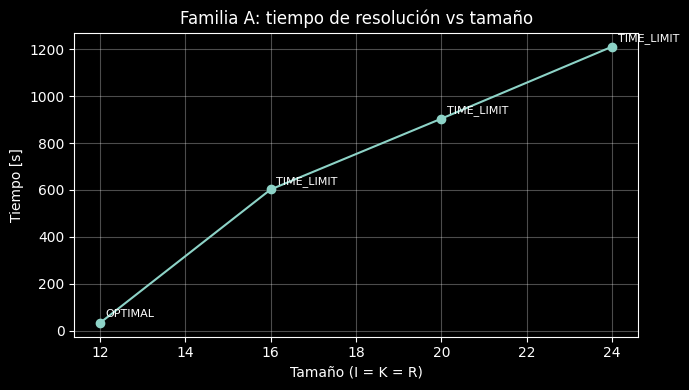

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fa["I"], fa["runtime"], "o-")
for _, f in fa.iterrows():
    ax.annotate(f["status"], (f["I"], f["runtime"]), fontsize=8,
                textcoords="offset points", xytext=(4, 4))
ax.set_xlabel("Tamaño (I = K = R)"); ax.set_ylabel("Tiempo [s]")
ax.set_title("Familia A: tiempo de resolución vs tamaño")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAF / "A_tiempo_vs_tamano.png", dpi=150)
plt.show()

## Escalabilidad: gap vs tamaño

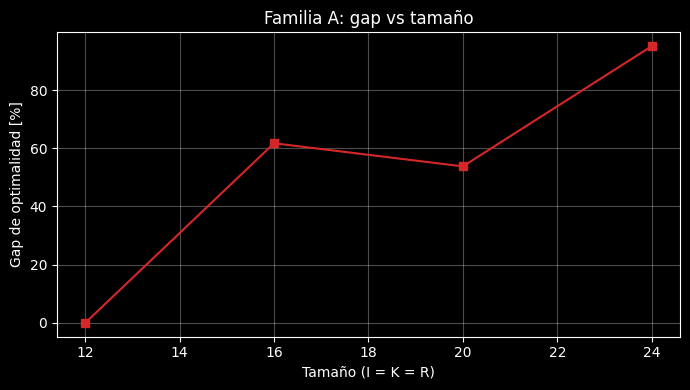

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fa["I"], 100 * fa["mip_gap"].fillna(np.nan), "s-", color="tab:red")
ax.set_xlabel("Tamaño (I = K = R)"); ax.set_ylabel("Gap de optimalidad [%]")
ax.set_title("Familia A: gap vs tamaño")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAF / "A_gap_vs_tamano.png", dpi=150)
plt.show()

## Complejidad: num_z vs runtime

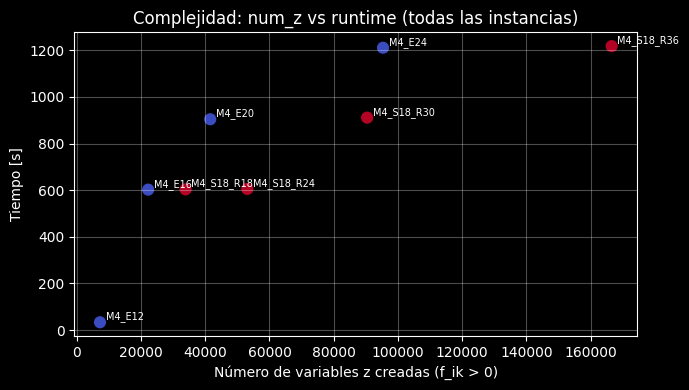

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df["num_z"], df["runtime"], c=(df["familia"] == "B_sobreoferta"),
           cmap="coolwarm", s=60)
for _, f in df.iterrows():
    ax.annotate(f["instancia"], (f["num_z"], f["runtime"]), fontsize=7,
                textcoords="offset points", xytext=(4, 2))
ax.set_xlabel("Número de variables z creadas (f_ik > 0)")
ax.set_ylabel("Tiempo [s]")
ax.set_title("Complejidad: num_z vs runtime (todas las instancias)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAF / "numz_vs_runtime.png", dpi=150)
plt.show()

## Mejora frente al azar

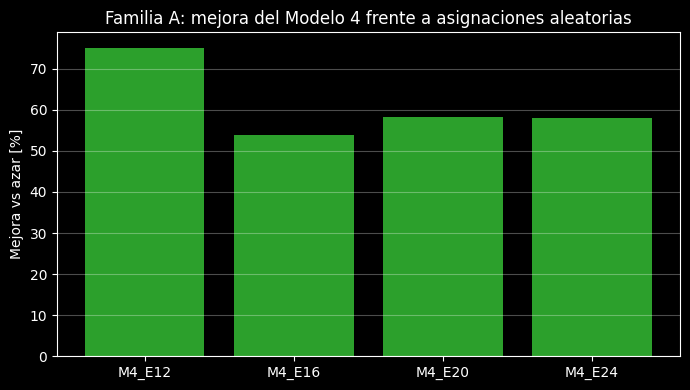

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fa["instancia"], fa["mejora_vs_azar"], color="tab:green")
ax.set_ylabel("Mejora vs azar [%]")
ax.set_title("Familia A: mejora del Modelo 4 frente a asignaciones aleatorias")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(DIR_GRAF / "A_mejora_vs_azar.png", dpi=150)
plt.show()

## Sobreoferta: costo vs número de salas

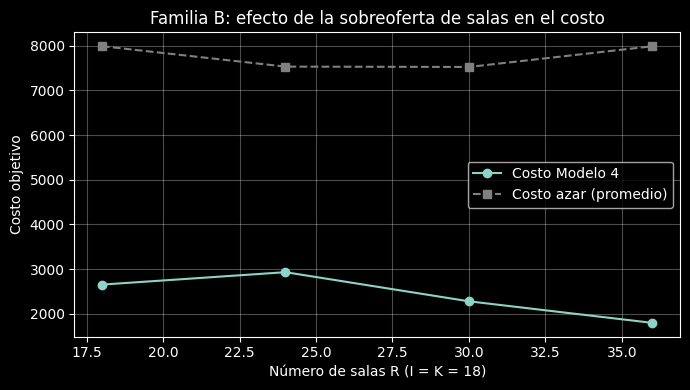

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fb["R"], fb["obj_modelo"], "o-", label="Costo Modelo 4")
ax.plot(fb["R"], fb["costo_azar_promedio"], "s--", color="gray",
        label="Costo azar (promedio)")
ax.set_xlabel("Número de salas R (I = K = 18)")
ax.set_ylabel("Costo objetivo")
ax.set_title("Familia B: efecto de la sobreoferta de salas en el costo")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAF / "B_costo_vs_salas.png", dpi=150)
plt.show()

## Sobreoferta: runtime y gap

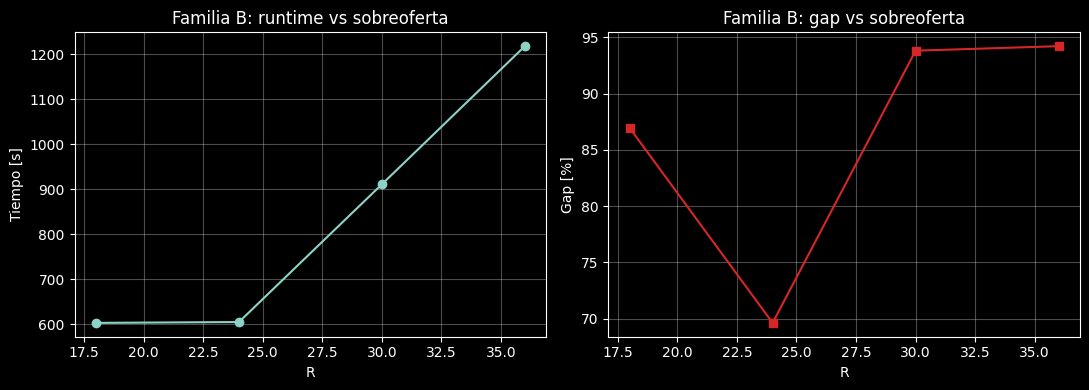

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(fb["R"], fb["runtime"], "o-")
ax1.set_xlabel("R"); ax1.set_ylabel("Tiempo [s]")
ax1.set_title("Familia B: runtime vs sobreoferta"); ax1.grid(alpha=0.3)
ax2.plot(fb["R"], 100 * fb["mip_gap"].fillna(np.nan), "s-", color="tab:red")
ax2.set_xlabel("R"); ax2.set_ylabel("Gap [%]")
ax2.set_title("Familia B: gap vs sobreoferta"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAF / "B_runtime_gap.png", dpi=150)
plt.show()

## Estudiantes por tipo de transición

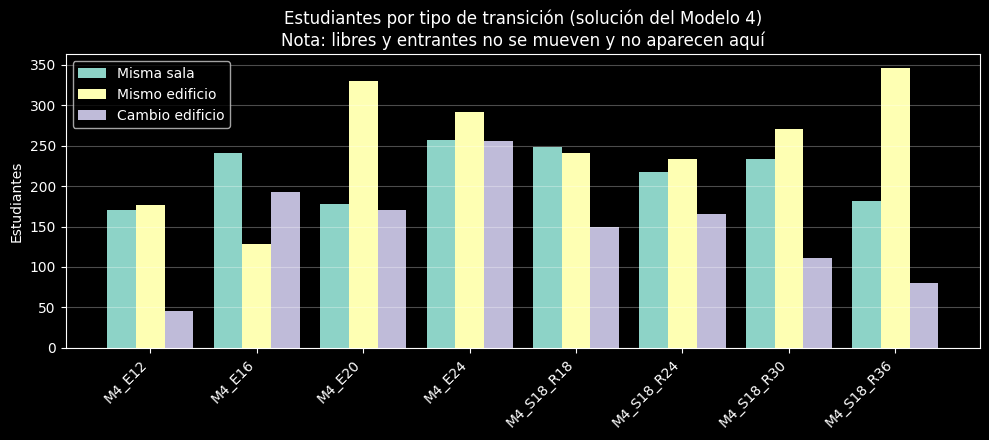

In [9]:
d = df.dropna(subset=["obj_modelo"])
xpos = np.arange(len(d)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(xpos - w, d["estudiantes_misma_sala"], w, label="Misma sala")
ax.bar(xpos,     d["estudiantes_mismo_edificio"], w, label="Mismo edificio")
ax.bar(xpos + w, d["estudiantes_cambio_edificio"], w, label="Cambio edificio")
ax.set_xticks(xpos); ax.set_xticklabels(d["instancia"], rotation=45, ha="right")
ax.set_ylabel("Estudiantes")
ax.set_title("Estudiantes por tipo de transición (solución del Modelo 4)\n"
             "Nota: libres y entrantes no se mueven y no aparecen aquí")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(DIR_GRAF / "estudiantes_por_transicion.png", dpi=150)
plt.show()

## Asignación representativa

In [10]:
# Asignación representativa: instancia factible más grande (mayor I + R).
d = df.dropna(subset=["obj_modelo"]).copy()
if len(d):
    d["tam_total"] = d["I"] + d["R"]
    nombre = d.sort_values("tam_total").iloc[-1]["instancia"]
    print(f"Instancia representativa: {nombre}")
    a1 = pd.read_csv(BASE / "outputs" / "asignaciones" / nombre /
                     "asignaciones_b1.csv")
    a2 = pd.read_csv(BASE / "outputs" / "asignaciones" / nombre /
                     "asignaciones_b2.csv")
    display(a1.head(15)); display(a2.head(15))
else:
    print("Ninguna instancia tiene solución factible reportada.")


Instancia representativa: M4_S18_R36


,curso_b1,tamano,sala,capacidad_sala,edificio
0,i1,26,r19,45,E3
1,i2,42,r34,45,E2
2,i3,40,r15,80,E3
3,i4,49,r6,50,E2
4,i5,44,r31,50,E3
5,i6,40,r26,45,E2
6,i7,22,r7,45,E3
7,i8,24,r22,35,E2
8,i9,32,r27,40,E3
9,i10,33,r18,40,E2


,curso_b2,tamano,sala,capacidad_sala,edificio
0,k1,35,r11,80,E3
1,k2,40,r34,45,E2
2,k3,35,r19,45,E3
3,k4,49,r6,50,E2
4,k5,31,r31,50,E3
5,k6,43,r26,45,E2
6,k7,31,r7,45,E3
7,k8,18,r22,35,E2
8,k9,20,r27,40,E3
9,k10,37,r18,40,E2


## Complejidad y escalabilidad

**Conteo de variables `z`.** El número de variables de linealización no es
`|I|·|K|·|R|²`. Esa expresión es solo una **cota superior teórica**, que se
daría si todos los flujos fueran positivos y todas las salas factibles para
todos los cursos. El modelo crea `z` únicamente para pares de cursos con
flujo positivo y para salas factibles por capacidad, de modo que el conteo
real es:

`num_z = Σ_{(i,k): f_ik > 0} |R_i| · |S_k|`

donde `R_i` y `S_k` son los conjuntos de salas con capacidad suficiente para
el curso `i` (bloque 1) y `k` (bloque 2), respectivamente. Esto explica por
qué, por ejemplo, E12 tiene 7.215 variables `z` y no las ~249.000 que daría
la cota superior. Aun así, el **orden de crecimiento** sigue siendo cuadrático
en el número de salas: `num_z` pasa de 7.215 (E12) a 95.361 (E24).

**Escalabilidad observada.** Solo **M4_E12 se resuelve a óptimo certificado**
(gap 0%, 33,24 s). Desde **M4_E16 en adelante todas las instancias de la
familia A terminan en estado TIME_LIMIT con gap positivo alto** (62%, 54% y
95% para E16, E20 y E24). El salto de dificultad aparece, por tanto, entre
12 y 16 cursos por bloque: con ~22.000 variables `z` el solver ya no certifica
optimalidad dentro del límite de tiempo.

Set parameter Username
Set parameter LicenseID to value 2808412
Academic license - for non-commercial use only - expires 2027-04-16


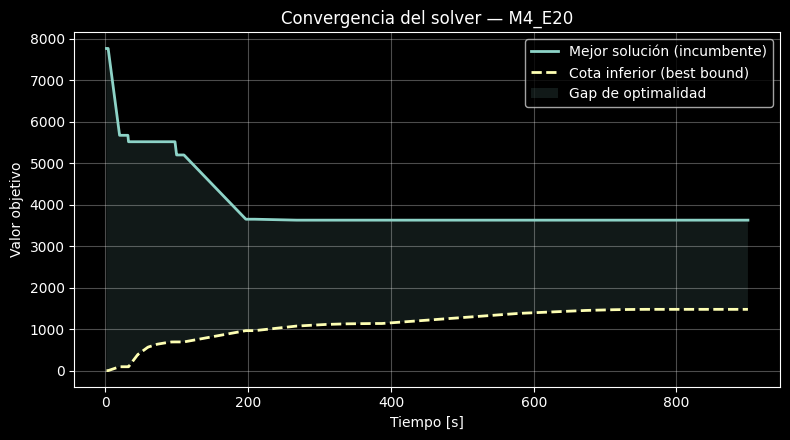

Incumbente final: 3628.8 | cota final: 1477.5 | gap final: 59.3%


In [11]:
# === Curva de convergencia: incumbente vs cota inferior (una instancia) ===
import gurobipy as gp
from gurobipy import GRB
import time

INSTANCIA = "M4_E20"          # instancia representativa de tamaño medio
TIME_LIMIT_CONV = 900

# --- cargar datos de la instancia ---
import sys
sys.path.append(str(BASE / "src"))
from resolver_modelo4 import cargar_instancia

inst_dir = BASE / "data" / "instancias_modelo4" / INSTANCIA
d = cargar_instancia(inst_dir)
I, K, R = d["I"], d["K"], d["R"]
n, m, cap, F, c = d["n"], d["m"], d["cap"], d["F"], d["c"]

R_i = {i: [r for r in R if cap[r] >= n[i]] for i in I}
S_k = {k: [s for s in R if cap[s] >= m[k]] for k in K}

model = gp.Model("convergencia")
model.Params.OutputFlag = 0
model.Params.TimeLimit = TIME_LIMIT_CONV

x = model.addVars([(i, r) for i in I for r in R_i[i]], vtype=GRB.BINARY, name="x")
y = model.addVars([(k, s) for k in K for s in S_k[k]], vtype=GRB.BINARY, name="y")
zc = [(i, k, r, s) for (i, k) in F for r in R_i[i] for s in S_k[k]]
z = model.addVars(zc, lb=0.0, ub=1.0, name="z")

model.addConstrs(gp.quicksum(x[i, r] for r in R_i[i]) == 1 for i in I)
model.addConstrs(gp.quicksum(y[k, s] for s in S_k[k]) == 1 for k in K)
model.addConstrs(gp.quicksum(x[i, r] for i in I if r in R_i[i]) <= 1 for r in R)
model.addConstrs(gp.quicksum(y[k, s] for k in K if s in S_k[k]) <= 1 for s in R)
model.addConstrs(z[i, k, r, s] <= x[i, r] for (i, k, r, s) in zc)
model.addConstrs(z[i, k, r, s] <= y[k, s] for (i, k, r, s) in zc)
model.addConstrs(z[i, k, r, s] >= x[i, r] + y[k, s] - 1 for (i, k, r, s) in zc)
model.setObjective(
    gp.quicksum(F[(i, k)] * c[(r, s)] * z[i, k, r, s] for (i, k, r, s) in zc),
    GRB.MINIMIZE)

# --- callback: registra (tiempo, mejor solución, mejor cota) ---
traza = []
t0 = time.time()
def cb(mdl, where):
    if where == GRB.Callback.MIP:
        obj = mdl.cbGet(GRB.Callback.MIP_OBJBST)
        bnd = mdl.cbGet(GRB.Callback.MIP_OBJBND)
        if obj < GRB.INFINITY:
            traza.append((time.time() - t0, obj, bnd))

model.optimize(cb)

# --- graficar ---
conv = pd.DataFrame(traza, columns=["t", "incumbente", "cota"])
conv = conv[conv["t"] > 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(conv["t"], conv["incumbente"], label="Mejor solución (incumbente)", lw=2)
ax.plot(conv["t"], conv["cota"], label="Cota inferior (best bound)", lw=2, ls="--")
ax.fill_between(conv["t"], conv["cota"], conv["incumbente"], alpha=0.12,
                label="Gap de optimalidad")
ax.set_xlabel("Tiempo [s]"); ax.set_ylabel("Valor objetivo")
ax.set_title(f"Convergencia del solver — {INSTANCIA}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAF / f"convergencia_{INSTANCIA}.png", dpi=150)
plt.show()

print(f"Incumbente final: {conv['incumbente'].iloc[-1]:.1f} | "
      f"cota final: {conv['cota'].iloc[-1]:.1f} | "
      f"gap final: {100*(1-conv['cota'].iloc[-1]/conv['incumbente'].iloc[-1]):.1f}%")

## Conclusiones

**Gap de optimalidad.** A partir de E16 los gaps son altos (54%–95%). Un gap
alto **no implica que la solución sea mala**, pero tampoco permite afirmar que
sea óptima ni cercana al óptimo: significa únicamente que el solver **no logró
certificar la cercanía al óptimo** dentro del límite de tiempo. La curva de
convergencia sugiere que la causa es una **cota inferior débil** (el incumbente
se estabiliza pronto mientras la cota sube muy lentamente), comportamiento
habitual en la relajación lineal de McCormick. Toda instancia con TIME_LIMIT se
reporta como **solución factible sin optimalidad certificada**.

**Mejora frente al azar.** Las soluciones del Modelo 4 mejoran entre
aproximadamente **54% y 78%** respecto a 10 asignaciones aleatorias factibles,
en todas las instancias. Esto es **evidencia empírica de utilidad práctica**
—el modelo entrega asignaciones claramente mejores que una asignación sin
criterio— pero **no constituye una prueba de optimalidad**.

**Sobreoferta de salas (familia B).** Más salas aportan más flexibilidad de
asignación, pero la relación observada **no es monotónica**: al pasar de R=18
a R=24 el costo sube (2.652 → 2.930) antes de bajar en R=30 y R=36. Hay dos
razones para no sobreinterpretar estos costos: (1) los gaps elevados hacen que
los valores objetivo entre instancias B no sean estrictamente comparables; y
(2) **limitación metodológica:** la familia B no es anidada —cada instancia
regenera cursos, flujos y salas con distinta semilla—, por lo que no mide el
efecto marginal puro de *agregar* salas. Un análisis marginal estricto
requeriría mantener fijos cursos, flujos y salas base, añadiendo solo salas
adicionales. Lo que sí es robusto y monótono es el número de **salas sin usar**,
que crece de 0 a 18 conforme aumenta R, confirmando la holgura creciente.

**Movilidad en el campus (transiciones).** La descomposición de estudiantes en
*misma sala*, *mismo edificio* y *cambio de edificio* conecta directamente el
modelo con la movilidad física real: cada categoría representa un nivel
creciente de desplazamiento entre bloques consecutivos. Comparada con el azar,
la solución del Modelo 4 concentra mucho más flujo en *misma sala* y *mismo
edificio*, reduciendo los cambios de edificio, que son los más costosos.

**Conclusión global.** El Modelo 4 con linealización exacta de McCormick es
**adecuado para certificar el óptimo solo en instancias pequeñas** (≈12 cursos
por bloque). Para tamaños mayores deja de ser tratable en tiempo razonable,
aunque entrega soluciones factibles de utilidad práctica demostrable frente al
azar. El estudio cumple su objetivo: caracterizar empíricamente la
**escalabilidad, los tiempos de respuesta y el gap** de la formulación, y
dimensionar su frontera de aplicabilidad.